# Homework 08 — Exploratory Data Analysis (EDA)

This notebook profiles a synthetic financial-behavior dataset (the starter's generator, since no
project dataset is provided), visualizes distributions and relationships, reads the time axis, and
documents the insights, assumptions, and risks that feed the next two stages (feature engineering
in stage 09, time-series modeling/splitting in stage 10b).

The reusable profiling helper lives in `src/eda.py` and is imported and called below.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib

In [2]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path
import sys

HOMEWORK_DIR = Path.cwd()
ROOT = HOMEWORK_DIR
SRC_DIR = ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('Homework directory:', HOMEWORK_DIR)
print('Source directory:', SRC_DIR)

CHECKS = [
    ('src/eda.py', 'NEEDED', 'YOU write this in the homework - the import fails until you do'),
]

print(f'Looking in: {ROOT}\n')
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == 'NEEDED':
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<28}  {note}")

if missing:
    print(f'\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}')
else:
    print('\nAll needed files present.')

Homework directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework08
Source directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework08/src
Looking in: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework08

  [OK ]  NEEDED    src/eda.py                    YOU write this in the homework - the import fails until you do

All needed files present.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North', 'South', 'East', 'West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions'] * 18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max() + 12

df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [4]:
df.info()
print('\nMissing values:')
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[us]
 1   region        160 non-null    str           
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 8.3 KB

Missing values:


date            0
region          0
age             0
income          5
transactions    0
spend           3
dtype: int64

## 2) Numeric profile

`describe()` covers the four numeric columns; I add **skew** and **kurtosis** because a bell-shaped
summary hides the shape. Three things stand out below:

- `income` is **right-skewed** (skew ≈ 0.99) — it is log-normal by construction.
- `transactions` is **very right-skewed** (skew ≈ 3.47, kurtosis ≈ 20) — a count variable with two
  extreme spikes (`max = 20`).
- `age` and `spend` are roughly symmetric (skew near 0).

In [5]:
desc = df[['age', 'income', 'transactions', 'spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.019,8.459,22.00,34.70,40.15,44.925,61.10,0.070,-0.080
income,155.0,41983.866,13262.457,17928.80,32471.53,39332.52,49697.690,87052.40,0.993,0.919
transactions,160.0,3.238,2.586,0.00,2.00,3.00,4.000,20.00,3.466,19.985
spend,157.0,117.292,51.769,0.54,77.25,119.32,153.340,280.05,0.131,-0.085


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs its own
look: how many distinct values it has, how lopsided the split is, and whether one category
dominates so heavily it would be useless as a feature.

The non-numeric columns here are `region` (a true categorical) and `date` (a datetime — I profile
it separately in the time section).

non-numeric columns: ['date', 'region']

date: datetime range 2021-02-01 00:00:00 -> 2021-07-10 00:00:00 (160 unique)

region — value counts:
region
West     47
East     42
South    36
North    35
region — proportions:
region
West     0.294
East     0.262
South    0.225
North    0.219


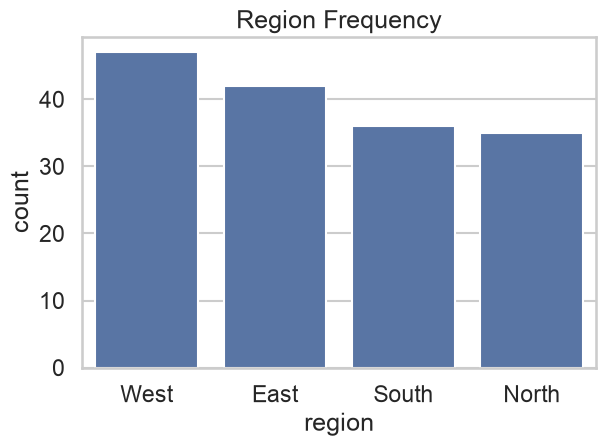

In [6]:
# Value counts AND proportions for every non-numeric column.
non_numeric = df.select_dtypes(exclude='number').columns.tolist()
print('non-numeric columns:', non_numeric)

for c in non_numeric:
    if pd.api.types.is_datetime64_any_dtype(df[c]):
        print(f'\n{c}: datetime range {df[c].min()} -> {df[c].max()} ({df[c].nunique()} unique)')
        continue
    print(f'\n{c} — value counts:')
    print(df[c].value_counts().to_string())
    print(f'{c} — proportions:')
    print(df[c].value_counts(normalize=True).round(3).to_string())

# Plot the categorical column.
sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.title('Region Frequency')
plt.tight_layout()
plt.show()

## 3) Distributions

Three distributions, one per shape that matters. The boxplot on `transactions` makes the two
spikes visible as points far past the whiskers; the two histograms show the right-skew of `income`
and the near-symmetry of `spend`.

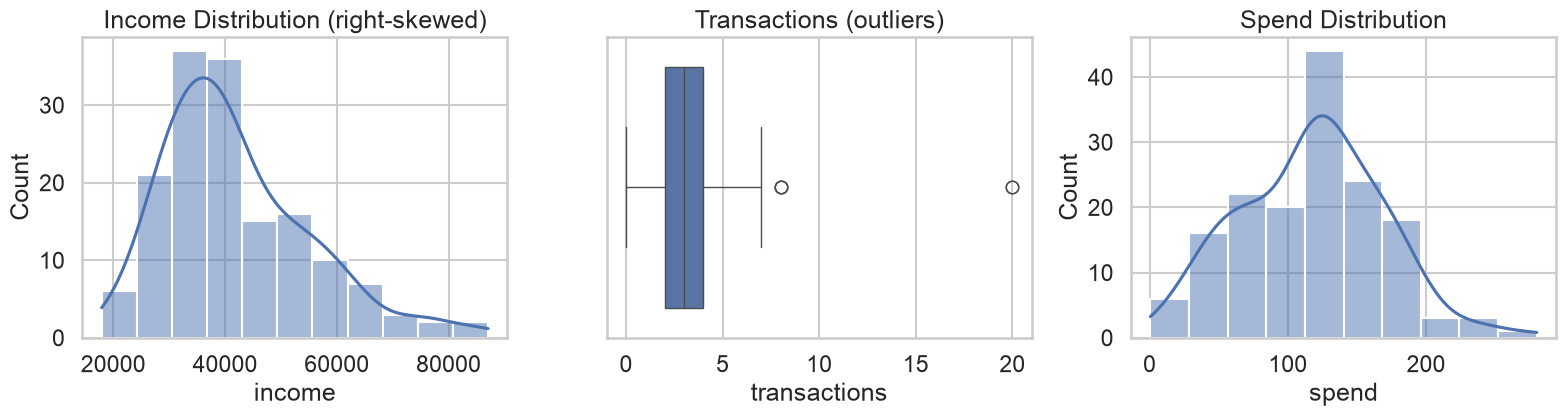

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df['income'], kde=True, ax=axes[0])
axes[0].set_title('Income Distribution (right-skewed)')

sns.boxplot(x=df['transactions'], ax=axes[1])
axes[1].set_title('Transactions (outliers)')

sns.histplot(df['spend'], kde=True, ax=axes[2])
axes[2].set_title('Spend Distribution')

fig.tight_layout()
plt.show()

## 4) Relationships

Three bivariate looks. `income` and `transactions` both push `spend` up (the generator's spend
formula is `income * 0.0015 + transactions * 18 + noise`), while `age` does **not** enter the
formula — so the `age` vs `spend` panel should show a flat cloud, and it does.

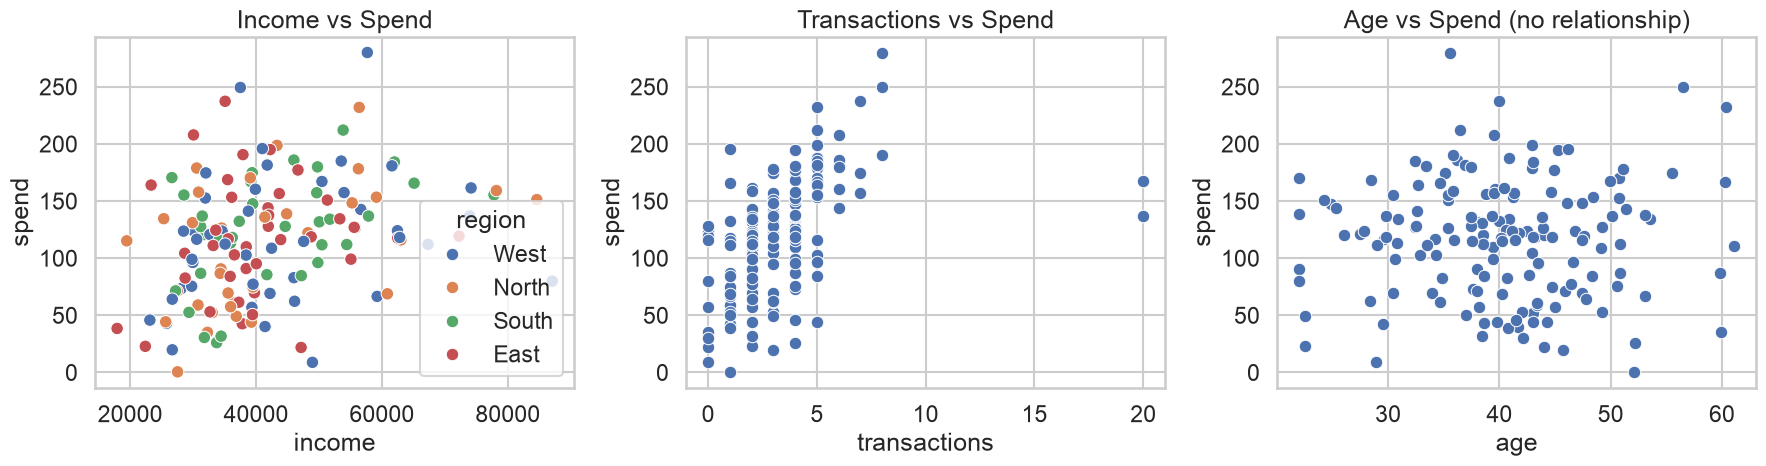

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='income', y='spend', hue='region', ax=axes[0])
axes[0].set_title('Income vs Spend')

sns.scatterplot(data=df, x='transactions', y='spend', ax=axes[1])
axes[1].set_title('Transactions vs Spend')

sns.scatterplot(data=df, x='age', y='spend', ax=axes[2])
axes[2].set_title('Age vs Spend (no relationship)')

fig.tight_layout()
plt.show()

## 4b) Over time

Nothing above uses `date`. A dataset with a date almost always has something to say along it: a
trend, a seasonal cycle, or a level shift. I sort by `date`, set it as the index, check for gaps,
and plot with a rolling mean so the ordering is respected before stage 09/10b build on this axis.

expected days: 160 | actual rows: 160 | missing dates: 0


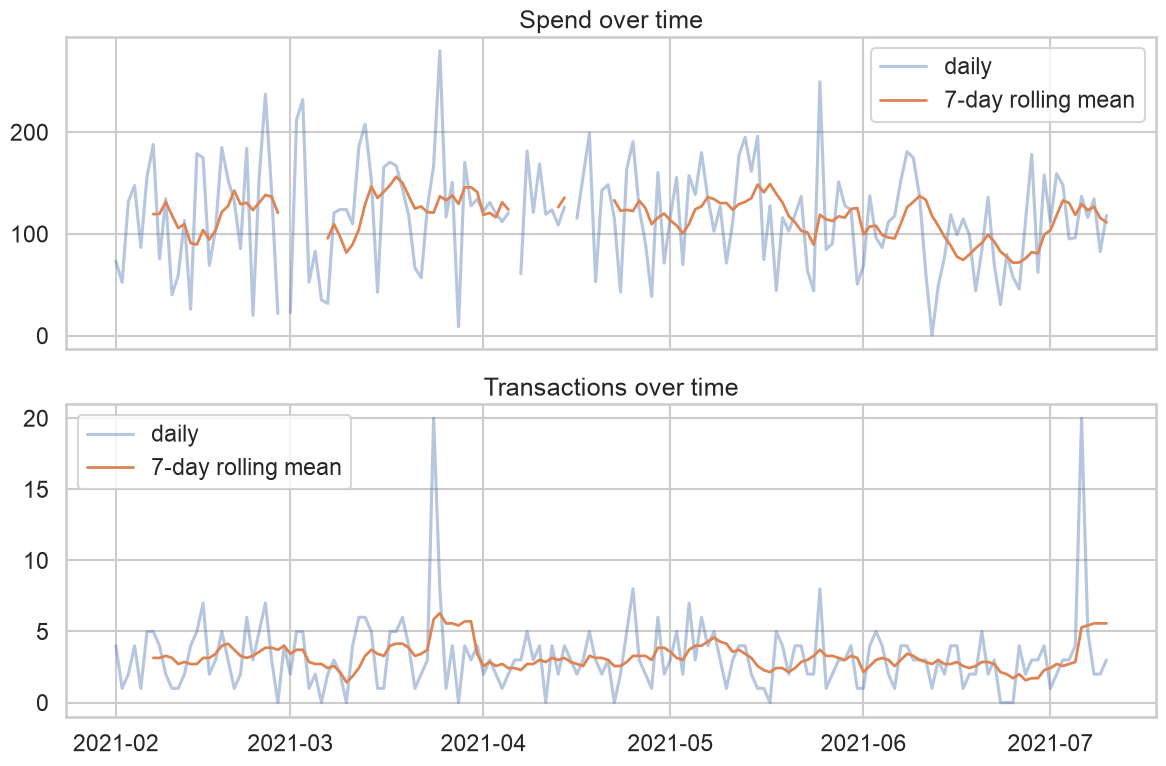

In [9]:
# Sort by date and set as index before any rolling / resample.
ts = df.sort_values('date').set_index('date')

# Check for GAPS: a rolling window spanning a missing week is not the window you think it is.
full_dates = pd.date_range(ts.index.min(), ts.index.max(), freq='D')
gaps = full_dates.difference(ts.index)
print(f'expected days: {len(full_dates)} | actual rows: {len(ts)} | missing dates: {len(gaps)}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(ts.index, ts['spend'], alpha=0.4, label='daily')
axes[0].plot(ts.index, ts['spend'].rolling(7).mean(), label='7-day rolling mean', lw=2)
axes[0].set_title('Spend over time')
axes[0].legend()

axes[1].plot(ts.index, ts['transactions'], alpha=0.4, label='daily')
axes[1].plot(ts.index, ts['transactions'].rolling(7).mean(), label='7-day rolling mean', lw=2)
axes[1].set_title('Transactions over time')
axes[1].legend()

fig.tight_layout()
plt.show()

### Time-series read

**Trend: none.** The 7-day rolling means sit flat around ≈117 (`spend`) and ≈3 (`transactions`) — no
upward or downward drift.

**Seasonality: none.** The generator is date-agnostic, so no day-of-week or monthly cycle exists by
construction, and the plots confirm it (the rolling line does not oscillate). Only ~5.5 months of
data are present, so a yearly cycle could not be seen anyway.

**Level shift: none.** The only structure on the time axis is two isolated spikes in `transactions`
(2021-03-24 and 2021-07-06, value = 20). These are point outliers, not a sustained change in level.

**Gaps: none** (160 expected days, 160 rows).

**What this implies for the next stages.** For stage 09, the absence of trend/seasonality means lag
and rolling features built on *this* synthetic series would be capturing noise rather than signal —
in a real dataset this is exactly the place where you would first confirm the time structure, then
build day-of-week / lag / rolling features only if that structure is real. For stage 10b, since
there is no trend to extrapolate and no seasonality to leak, a time-ordered split is still the safe
default, but I would not expect a trend model to beat a level model on this data.

## 5) (Optional) Correlation matrix

The heatmap shows which pairs actually matter for modeling: `transactions ↔ spend` (0.48) and
`income ↔ spend` (0.31) are the meaningful ones; `age` is ~0 with everything (it never enters the
spend formula), so it is noise as a predictor of `spend`.

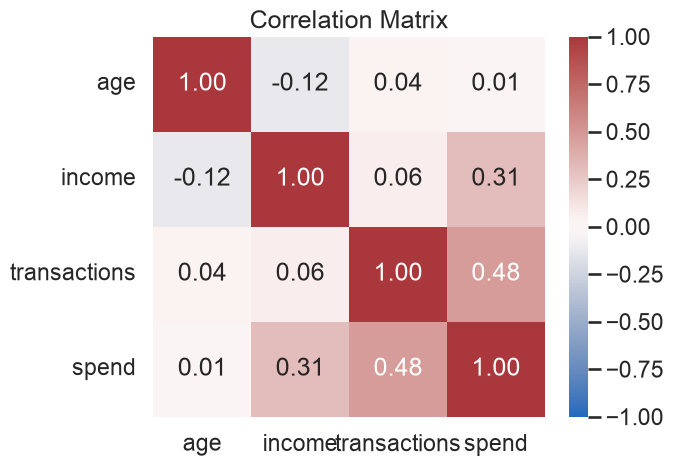

,age,income,transactions,spend
age,1.000,-0.123,0.038,0.008
income,-0.123,1.000,0.064,0.307
transactions,0.038,0.064,1.000,0.481
spend,0.008,0.307,0.481,1.000


In [10]:
corr = df[['age', 'income', 'transactions', 'spend']].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()
corr.round(3)

## 5b) Your reusable helper — `src/eda.py`

The lecture builds `eda_summary(df)` in its section 8. I copied it into `src/eda.py`, extended it
with a categorical profile and a `flag_columns()` attention-flagger, and import it here. The point
is one profiling function for the project instead of ten pasted copies.

In [11]:
from src.eda import eda_summary, flag_columns

summary = eda_summary(df)

print('shape:', summary['shape'])
print('\nmissing:')
print(summary['missing'])
print('\nnumeric profile:')
display(summary['numeric_profile'].round(3))
print('\ncategorical profile:')
display(summary['categorical_profile'].round(3))
print('\nflags (empty = nothing needs urgent attention before stage 09):')
display(summary['flags'])

shape: (160, 6)

missing:
{'date': 0, 'region': 0, 'age': 0, 'income': 5, 'transactions': 0, 'spend': 3}

numeric profile:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.019,8.459,22.00,34.70,40.15,44.925,61.10,0.070,-0.080
income,155.0,41983.866,13262.457,17928.80,32471.53,39332.52,49697.690,87052.40,0.993,0.919
transactions,160.0,3.238,2.586,0.00,2.00,3.00,4.000,20.00,3.466,19.985
spend,157.0,117.292,51.769,0.54,77.25,119.32,153.340,280.05,0.131,-0.085



categorical profile:


,column,dtype,n_unique,missing,top_category,top_share
0,date,datetime64[us],160,0,2021-02-01 00:00:00,0.006
1,region,str,4,0,West,0.294



flags (empty = nothing needs urgent attention before stage 09):


""


### `flag_columns()` catches the three problems (stretch demo)

On the real `df`, `flag_columns()` returns nothing — the data is clean enough that no column trips
the thresholds. To show the flagger works, here it is on a tiny toy frame with one problem each: a
90%-missing column, a constant column, and a column where one category is 95% of the rows.

In [12]:
toy = pd.DataFrame({
    'mostly_missing': [np.nan] * 9 + [1.0],
    'constant': [5.0] * 10,
    'one_category': ['A'] * 9 + ['B'],
})
flag_columns(toy, missing_thresh=0.05, dominant_thresh=0.80)

,column,dtype,reasons
0,mostly_missing,float64,high missingness (90.0%); near-zero variance
1,constant,float64,near-zero variance
2,one_category,str,one category dominates (90.0%)


## 5c) Two granularities (stretch): daily vs monthly

Aggregating to the month smooths the daily noise. Two things surface at this granularity: (1) the
per-day means are stable month to month (no trend), and (2) **July is a partial month** — only 10
days — so its *sums* are misleadingly small even though its *means* are in line. That is the classic
boundary artifact to watch before building monthly features.

In [13]:
monthly = ts[['transactions', 'spend']].resample('ME').agg(['sum', 'mean'])
monthly.round(2)

transactions          spend        
                    sum  mean      sum    mean
date                                          
2021-02-28           92  3.29  3128.33  115.86
2021-03-31          115  3.71  3908.99  126.10
2021-04-30           88  2.93  3431.53  122.55
2021-05-31           99  3.19  3804.13  122.71
2021-06-30           79  2.63  2942.56   98.09
2021-07-31           45  4.50  1199.24  119.92

## 6) Insights & Assumptions

### Top 3 insights

1. **`transactions` is the strongest driver of `spend` (r ≈ 0.48), `income` second (r ≈ 0.31), and
   `age` is irrelevant (r ≈ 0).** For stage 09, `age` is a drop candidate as a spend predictor, and
   the model should lean on `transactions` and `income`.

2. **Two `transactions` rows are extreme spikes (value 20 vs. a median of 3) whose `spend` is
   unremarkable (~137 and ~167).** They were injected *after* `spend` was computed, so they are a
   data-quality flag: either the counts are errors, or `spend` failed to capture the activity. They
   should be verified/capped (winsorized) before modeling, not silently kept.

3. **The time axis is stationary noise: no trend, no seasonality, no level shift, no gaps.** This
   is a real (if boring) finding — it tells stage 09 not to expect lag/rolling features to add
   signal here, and stage 10b not to expect a trend model to help.

### Assumptions & risks

- **Missingness (5 in `income`, 3 in `spend`) is treated as ignorable for EDA** — the plots drop
  those rows implicitly. Risk: if the missingness is *not* at random, the profile of the remaining
  rows is biased. Stage 06 already decided the imputation strategy; stage 09 must apply it before
  modeling.
- **The two transaction spikes are assumed to be outliers, not a regime change.** Risk: if they are
  genuine (a real surge), capping them hides tail behavior — the exact lesson from stage 07.
- **Daily granularity is assumed to be the right level.** If the real question is monthly behavior,
  some daily noise (and the partial-July boundary) is irrelevant — the monthly view is the one to
  model.

### Next steps before modeling (cleaning & features)

- Impute the missing `income` and `spend` (median, per stage 06) and **flag missingness as a feature**.
- **Winsorize or verify** the two `transactions` spikes.
- **Log-transform `income`** (right-skewed) before any linear model.
- Build features on the two signal pairs (`transactions`, `income`) and consider dropping `age`.
- No lag/rolling features are warranted on this stationary series; revisit only if a real dataset
  shows trend or seasonality.